Shape: (95662, 16)

Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 95662 entries, 0 to 95661
Data columns (total 16 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   TransactionId         95662 non-null  object 
 1   BatchId               95662 non-null  object 
 2   AccountId             95662 non-null  object 
 3   SubscriptionId        95662 non-null  object 
 4   CustomerId            95662 non-null  object 
 5   CurrencyCode          95662 non-null  object 
 6   CountryCode           95662 non-null  int64  
 7   ProviderId            95662 non-null  object 
 8   ProductId             95662 non-null  object 
 9   ProductCategory       95662 non-null  object 
 10  ChannelId             95662 non-null  object 
 11  Amount                95662 non-null  float64
 12  Value                 95662 non-null  int64  
 13  TransactionStartTime  95662 non-null  object 
 14  PricingStrategy       95662 non-null  int64 

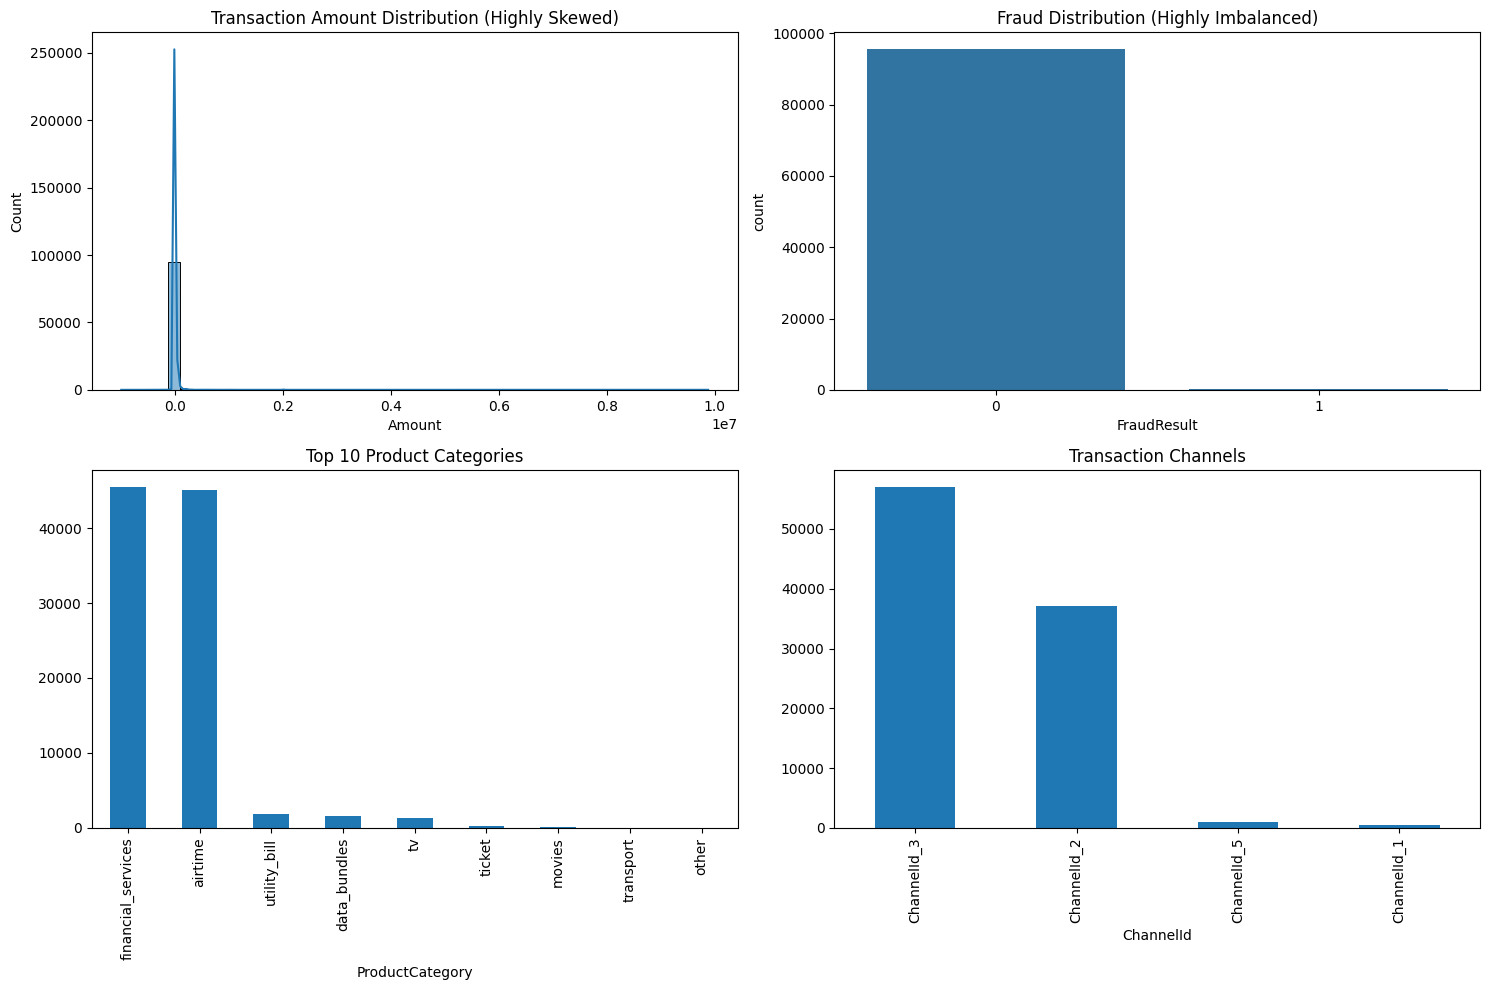

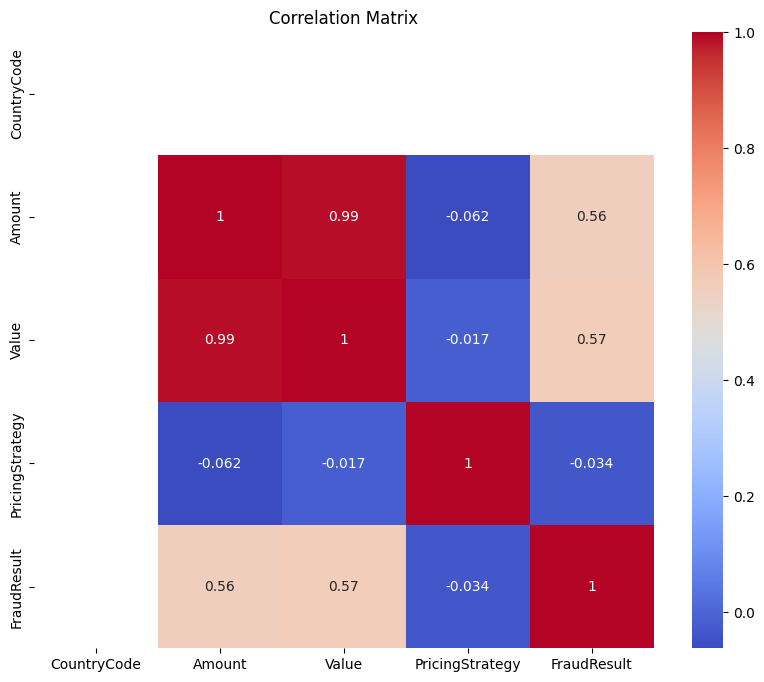

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

# Load data
df = pd.read_csv('../data/raw/transactions.csv')   

print("Shape:", df.shape)
print("\nInfo:")
print(df.info())
print("\nMissing Values:")
print(df.isnull().sum())

# Summary Statistics
print("\nDescribe:")
print(df.describe())

# Key Visualizations
plt.figure(figsize=(15, 10))

# 1. Amount Distribution
plt.subplot(2,2,1)
sns.histplot(df['Amount'], kde=True, bins=50) # type: ignore
plt.title('Transaction Amount Distribution (Highly Skewed)')

# 2. Fraud Distribution
plt.subplot(2,2,2)
sns.countplot(x='FraudResult', data=df)
plt.title('Fraud Distribution (Highly Imbalanced)')

# 3. Top Product Categories
plt.subplot(2,2,3)
df['ProductCategory'].value_counts().head(10).plot(kind='bar')
plt.title('Top 10 Product Categories')

# 4. Channel Distribution
plt.subplot(2,2,4)
df['ChannelId'].value_counts().plot(kind='bar')
plt.title('Transaction Channels')

plt.tight_layout()
plt.show()

# Correlation
numeric = df.select_dtypes(include=np.number)
corr = numeric.corr()
plt.figure(figsize=(10,8))
sns.heatmap(corr, annot=True, cmap='coolwarm')
plt.title('Correlation Matrix')
plt.show()

In [3]:
import pandas as pd

df = pd.read_csv('../data/raw/transactions.csv')  # update path if needed

# Convert time
df['TransactionStartTime'] = pd.to_datetime(df['TransactionStartTime'])

print("Number of Unique Customers:", df['CustomerId'].nunique())
print("Average transactions per customer:", len(df) / df['CustomerId'].nunique())

# Top 10 customers by transaction count
print("\nTop 10 Active Customers:")
print(df['CustomerId'].value_counts().head(10))

Number of Unique Customers: 3742
Average transactions per customer: 25.564404061998932

Top 10 Active Customers:
CustomerId
CustomerId_7343    4091
CustomerId_3634    2085
CustomerId_647     1869
CustomerId_1096     784
CustomerId_4033     778
CustomerId_3066     612
CustomerId_2528     610
CustomerId_2728     586
CustomerId_3078     573
CustomerId_806      557
Name: count, dtype: int64
